# Embryo Diffusion — Next‑Frame Prediction (silver F0)

This notebook trains a **context‑conditioned diffusion model** to predict the next frame from the last $k$ context frames. Training optimizes **noise‑prediction MSE** (with optional inversion regularizer), supports **ReduceLROnPlateau** LR scheduling, and includes **newest‑frame corruption** for robustness.  

**What it does**
- Builds a cached index from *silver* frames and phase CSVs.
- Splits by **embryo ID** to avoid leakage.
- Trains a UNet to predict noise on the target frame, conditioned on the $k$ previous frames and an optional absolute frame index embedding.
- Uses DDPM for training schedule and DDIM for fast sampling/inversion.
- Optionally uses external **phase classifier guidance** during sampling only.

**Project structure (expected)**
```
thesis/
├── data/
│   └── embryo_dataset_silver/
│       └── <plane_id>/<embryo_id>/
│           ├── 00001.jpeg, 00002.jpeg, ...
│           └── <embryo_id>_phases.csv
├── classifier/
│   └── embryo_phase_models/
└── diffusion/
    ├── train_diffusion.ipynb
    ├── embryo_diffusion_models/
    └── diffusion_samples/
```

**Notes**
- Presence filtering is **not** run here; *silver* is already filtered.
- Training pairs are adjacent in time: context $[t-k+1..t]$ → target $t+1$.
- External classifier guidance (if enabled) is used **only at sampling**, not in the training loss.

## Notebook map
This notebook is long, so here is the high-level flow:
1. **Configuration & paths** — dataset locations, training hyperparameters, and guidance toggles.
2. **Imports + reproducibility** — libraries, seeds, and the phase label set.
3. **Indexing** — build a frame index from the *silver* dataset (cached on disk).
4. **Splits** — split **by embryo** to prevent leakage across train/val/test.
5. **Model & diffusion schedule** — UNet backbone and DDPM/DDIM schedulers.
6. **Dataset & loaders** — preprocessing utilities + context→target dataset.
7. **Sampling helpers** — model init + DDIM sampling/guidance utilities.
8. **Training** — loss, metrics, checkpoints, and sample visualizations.
9. **Inference utilities** — ad hoc sampling and multi-step rollouts.

## 1. Configuration
This cell defines all paths, data splits, training hyperparameters, and guidance switches.
If you opened the notebook from the repo root, it automatically points to the diffusion subfolder so paths stay correct.

In [1]:
# ==== CONFIG (edit as needed) ====
# This cell centralizes *all* the knobs for data paths, training, and sampling.
from pathlib import Path
import os

# DEBUG MODE: Set to True for quick testing with minimal data
DEBUG_MODE = False
VERBOSE = True  # extra logging for dataset/split diagnostics

# Project root resolution: if you open from repo root, auto-jump into /diffusion
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != 'diffusion':
    # try to infer if opened from repo root
    if (PROJECT_ROOT / 'diffusion').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'diffusion'

# Data roots
DATA_ROOT = PROJECT_ROOT.parent / 'data'
SILVER_ROOT = DATA_ROOT / 'embryo_dataset_silver'
FOCAL_PLANES = ['F0']#, 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']

# Context window (k previous frames) for next-frame prediction
CONTEXT_K = 7  # baseline (downsized: 5)

# Time conditioning with absolute frame index embedding
# The Time Map is a spatial conditioning channel from the absolute frame index.
# Helps the model with information about "where in time" the sample is.
USE_TIME_MAP = True
MAX_FRAME_INDEX = 500  # safe upper bound (dataset max ~450)
# TIME_EMB_DIM: Dimension of the learned time embedding vector for a single frame index.
TIME_EMB_DIM = 8       # smaller ok (baseline was 16)

# Context encoder for cross-attention
# CONTEXT_EMB_DIM: Dimension of the learned context embedding.
# It sets the size of the per-frame/context embedding used in cross-attention layers.
CONTEXT_EMB_DIM = 128  # baseline (downsized: 48/64)

# Outputs
OUT_MODELS_DIR = PROJECT_ROOT / 'embryo_diffusion_models'
OUT_SAMPLES_DIR = PROJECT_ROOT / 'diffusion_samples'
CACHE_DIR = PROJECT_ROOT / 'cache'
for d in (OUT_MODELS_DIR, OUT_SAMPLES_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Training hyperparameters
IMG_SIZE = 128           # baseline (downsized: 96)
BATCH_SIZE = 32          # baseline (downsized: 32/64)
LR = 1e-4  # learning rate
USE_LR_SCHEDULER = True  # LROnPlateau only
LR_MIN = 1e-7  # higher floor to avoid over-decay
EPOCHS = 1000 if not DEBUG_MODE else 6  # Reduced epochs for debug
GRAD_CLIP = 1.0  # Gradient clipping to prevent NaN
L1_X0_WEIGHT = 0.1  # weight for L1(x0_pred, x0) regularization
NUM_WORKERS = 8
VAL_SPLIT = 0.10
TEST_SPLIT = 0.10
SPLIT_SEED = 42

# Checkpointing/logging
RESUME_TRAINING = False  # whether to resume from LAST_CKPT_PATH if it exists
LAST_CKPT_PATH = OUT_MODELS_DIR / f'nextframe_ctxk{CONTEXT_K}_{IMG_SIZE}px_last.pt'
BEST_CKPT_PATH = OUT_MODELS_DIR / f'nextframe_ctxk{CONTEXT_K}_{IMG_SIZE}px_best.pt'
LOG_PATH = OUT_MODELS_DIR / 'log.txt'

# Diffusion process
TIMESTEPS = 600  # training timesteps
BETA_START, BETA_END = 1e-4, 2e-2 # How much noise is added at each step

# DDIM sampling/inversion, for fast sampling and optional inversion training
USE_DDIM_SAMPLING = True
DDIM_STEPS = 150  # baseline (downsized: 50)
DDIM_ETA = 0.0

# Inversion training (optional regularizer)
# Inversion reverses the forward diffusion process to map a real image back to its corresponding initial noise latent,
# enabling precise image editing and reconstruction. 
# By moving from \(t=0\) to \(t=T\) (adding noise) rather than denoising, 
# it finds the exact latent vector that, when reversed, reproduces the original input.
INVERSION_TRAINING = True  # baseline (downsized: False)
INVERSION_LAMBDA = 0.1
INVERSION_STEPS = 10
INVERSION_EVERY_N = 64
INVERSION_MAX_BATCH = 16

# Gradient checkpointing + AMP
USE_GRAD_CHECKPOINTING = True  # required for memory; keep enabled

# TF32 (Ampere+ matmul/conv speedup)
USE_TF32 = True

# Sampling visualization
SAMPLE_PLANES = ['F0', 'F-15', 'F30']  # baseline (downsized: ['F0'])
SAMPLES_PER_PLANE = 3                 # baseline (downsized: 1)

# Data augmentation (applied identically to context stack + target)
AUGMENT = True
AUGMENT_HFLIP = 0.5
AUGMENT_VFLIP = 0.1
AUGMENT_MAX_ROT = 5.0
AUGMENT_BRIGHTNESS = 0.1
AUGMENT_CONTRAST = 0.1

# Validation metrics (SSIM/LPIPS)
COMPUTE_VAL_METRICS = True
VAL_METRIC_SAMPLES = 64 # baseline (downsized: 64)
VAL_METRIC_MAX_BATCHES = 16       # baseline (downsized: 2)
METRIC_SEED = 123

# Loss weighting (min-SNR)
USE_MIN_SNR = True
MIN_SNR_GAMMA = 5.0

# Debug overrides
#if DEBUG_MODE:
#    NUM_WORKERS = 2
#    BATCH_SIZE = 4
#    DDIM_STEPS = 20
#    INVERSION_STEPS = 8
#    INVERSION_EVERY_N = 10
#    INVERSION_MAX_BATCH = 2
#    SAMPLE_PLANES = ['F0']
#    SAMPLES_PER_PLANE = 1

print('Project root:', PROJECT_ROOT)
print('Silver root:', SILVER_ROOT)
print('Focal planes:', FOCAL_PLANES)
print(f'Context window k={CONTEXT_K}')
print(f'Splits: val={VAL_SPLIT:.2f}, test={TEST_SPLIT:.2f}, seed={SPLIT_SEED}')
print(f'DDIM: steps={DDIM_STEPS}, eta={DDIM_ETA}, enabled={USE_DDIM_SAMPLING}')
print(f'Inversion training: {INVERSION_TRAINING} (lambda={INVERSION_LAMBDA}, steps={INVERSION_STEPS}, every={INVERSION_EVERY_N}, max_batch={INVERSION_MAX_BATCH})')
print(f'Grad checkpointing: {USE_GRAD_CHECKPOINTING}')
if DEBUG_MODE:
    print('⚠️  DEBUG_MODE is ON - using reduced data for testing')
for plane in FOCAL_PLANES:
    plane_dir = SILVER_ROOT / plane
    assert plane_dir.exists(), f"Silver {plane} folder not found: {plane_dir}"

Project root: /home/khasion/Projects/thesis/diffusion
Silver root: /home/khasion/Projects/thesis/data/embryo_dataset_silver
Focal planes: ['F0']
Context window k=7
Splits: val=0.10, test=0.10, seed=42
DDIM: steps=150, eta=0.0, enabled=True
Inversion training: True (lambda=0.1, steps=10, every=64, max_batch=16)
Grad checkpointing: True


## 2. Imports and small utilities
The notebook relies on **PyTorch** for training, **diffusers** for the UNet + schedulers, and **LPIPS** for perceptual validation metrics.

In [2]:
# Imports & utils
import math, random, glob, re, os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

# Perceptual metric
from lpips import LPIPS

# Diffusers library for UNet and schedulers
from diffusers import UNet2DConditionModel, DDPMScheduler, DDIMScheduler

# AMP (automatic mixed precision) flag
# Set to False to avoid CheckpointError
USE_AMP = torch.cuda.is_available()  # avoid CheckpointError (was True)
print(f'AMP enabled: {USE_AMP}')


# TQDM helper: force ETA/remaining to show consistently
TQDM_BAR_FORMAT = "{l_bar}{bar} {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"

def tqdm_bar(iterable, **kwargs):
    """Convenience wrapper with consistent progress-bar formatting."""
    return tqdm(iterable, leave=True, bar_format=TQDM_BAR_FORMAT, **kwargs)

AMP enabled: True


## 3. Reproducibility and label setup
We seed all relevant RNGs for reproducibility, pick the compute device, and define the ordered phase labels used throughout the notebook.

In [3]:
# Initialize seed and device (must be before using PHASE_LABELS in later cells)
def seed_everything(seed=42):
    """Make results reproducible across Python/NumPy/PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

if USE_TF32 and torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision('high')
print(f"TF32 enabled: {USE_TF32 and torch.cuda.is_available()}")

# Ordered list of morphokinetic phase labels (target classes)
PHASE_LABELS = ['pPB2','pPNa','pPNf','p2','p3','p4','p5','p6','p7','p8','p9+','pM','pSB','pB','pEB','pHB']
NUM_PHASES = len(PHASE_LABELS)

# Plane ID mapping (only uses planes in FOCAL_PLANES)
PLANE_TO_ID = {plane: i for i, plane in enumerate(FOCAL_PLANES)}
ID_TO_PLANE = {i: plane for plane, i in PLANE_TO_ID.items()}
NUM_PLANES = len(FOCAL_PLANES)

Using device: cuda
TF32 enabled: True


## 4. Build a frame index (cached)
We scan the *silver* dataset and build a table of frame paths + phase labels. This is cached to CSV so you do it once.

In [4]:
# Build frame index from all focal planes: phase CSV lives next to frames
# Output columns: embryo_id, plane, frame_num (1-based), path, phase_id
INDEX_CACHE = CACHE_DIR / 'silver_all_planes_frame_index.csv'

def build_index_from_silver():
    rows = []
    # For each focal plane
    for plane in FOCAL_PLANES:
        plane_root = SILVER_ROOT / plane
        embryo_ids = sorted([d.name for d in plane_root.iterdir() if d.is_dir()])
        # For each embryo id included in focal plane
        for eid in tqdm(embryo_ids, desc=f'Indexing {plane}'):
            folder = plane_root / eid
            ann_path = folder / f"{eid}_phases.csv"
            if not ann_path.exists():
                continue
            # Use .jpeg files (silver dataset uses .jpeg)
            img_files = sorted(glob.glob(str(folder / '*.jpeg')))
            if not img_files:
                continue
            # Extract frame numbers from filenames (00037.jpeg → 37)
            frame_numbers = {}
            # For each frame image file
            for f in img_files:
                basename = os.path.basename(f)
                m = re.search(r'(\d+)\.jpeg$', basename)
                if m:
                    frame_num = int(m.group(1))
                    frame_numbers[frame_num] = f
            
            # Parse CSV (phase, start, end) allowing labels like "t9 +"
            def _parse_phase_csv(path: Path):
                spans = []
                with open(path, 'r', encoding='utf-8') as fh:
                    for line in fh:
                        line = line.strip()
                        if not line:
                            continue
                        # normalize delimiters to spaces
                        line = re.sub(r"[;,]", " ", line)
                        line = re.sub(r"\s+", " ", line).strip()
                        m = re.match(r"^(.*?)(\d+)\s+(\d+)$", line)
                        if not m:
                            continue
                        phase_raw = m.group(1).strip()
                        start = int(m.group(2))
                        end = int(m.group(3))
                        spans.append((phase_raw, start, end))
                return spans
            
            # Phase must start with p, e.g., pPNA not tPNA
            def phase_to_id(ph: str):
                ph = str(ph).strip()
                ph = re.sub(r"\s+", "", ph)  # remove spaces like "t9 +"
                ph = ph.replace('t', 'p', 1) if ph.startswith('t') else ph
                return PHASE_LABELS.index(ph)
            label_spans = []
            for phase_raw, start, end in _parse_phase_csv(ann_path):
                try:
                    pid = phase_to_id(phase_raw)
                    label_spans.append((int(start), int(end), pid))
                except Exception:
                    pass
            # assign phase per frame using actual frame numbers from filenames
            for frame_num, path in frame_numbers.items():
                pid = None
                for s, e, p in label_spans:
                    if s <= frame_num <= e:  # frame_num is 1-based, matches CSV
                        pid = p
                        break
                if pid is None:
                    continue
                rows.append({'embryo_id': eid, 'plane': plane, 'frame_num': frame_num, 'path': path, 'phase_id': pid})
    return pd.DataFrame(rows)

### 4.1 Index caching
We cache the full frame index to speed up restarts. Delete the cache file if you change the dataset layout.

In [5]:
if INDEX_CACHE.exists():
    index_df = pd.read_csv(INDEX_CACHE)
else:
    index_df = build_index_from_silver()
    index_df.to_csv(INDEX_CACHE, index=False)

print('Indexed frames (full):', len(index_df))
print('Planes:', sorted(index_df['plane'].unique().tolist()))
index_df.head()

Indexed frames (full): 289675
Planes: ['F0']


,embryo_id,plane,frame_num,path,phase_id
0,AA83-7,F0,5,/home/khasion/Projects/thesis/data/embryo_data...,0
1,AA83-7,F0,6,/home/khasion/Projects/thesis/data/embryo_data...,0
2,AA83-7,F0,7,/home/khasion/Projects/thesis/data/embryo_data...,0
3,AA83-7,F0,8,/home/khasion/Projects/thesis/data/embryo_data...,0
4,AA83-7,F0,9,/home/khasion/Projects/thesis/data/embryo_data...,0


## 5. Train/val/test splits (by embryo)
We split **by embryo ID**, not by frame, to avoid leaking information across sets. Splits are cached on disk.

In [6]:
# Build embryo splits (no embryo appears in more than one split)
SPLIT_CACHE_STEM = (
    f"splits_embryo_phase_ctxk{CONTEXT_K}_"
    f"seed{SPLIT_SEED}_v{VAL_SPLIT}_t{TEST_SPLIT}"
    + ("_debug" if DEBUG_MODE else "")
)
TRAIN_SPLIT_CACHE = CACHE_DIR / f"{SPLIT_CACHE_STEM}_train.csv"
VAL_SPLIT_CACHE = CACHE_DIR / f"{SPLIT_CACHE_STEM}_val.csv"
TEST_SPLIT_CACHE = CACHE_DIR / f"{SPLIT_CACHE_STEM}_test.csv"

def stratified_split(ids: list[str], labels: dict[str, int], val_frac: float, test_frac: float, seed: int):
    """Stratified split by dominant phase label per embryo.
    Args:
        ids: List of embryo IDs to split.
        labels: Mapping from embryo ID to dominant phase label ID.
        val_frac: Fraction of embryos to assign to validation set.
        test_frac: Fraction of embryos to assign to test set.
        seed: Random seed for reproducibility.
    Returns:
        train_ids, val_ids, test_ids: Sets of embryo IDs for each split.
    """
    rng = np.random.RandomState(seed)
    train_ids, val_ids, test_ids = [], [], []
    by_label: dict[int, list[str]] = {}
    for eid in ids:
        by_label.setdefault(labels[eid], []).append(eid) # group by label, Example: by_label == {0: ['e1','e3'], 1: ['e2']}
    for label, group in by_label.items():
        group = list(group)
        rng.shuffle(group)
        n = len(group)
        n_test = int(round(n * test_frac))
        n_val = int(round(n * val_frac))
        n_test = min(n_test, n)
        n_val = min(n_val, n - n_test)
        test_ids.extend(group[:n_test])
        val_ids.extend(group[n_test:n_test + n_val])
        train_ids.extend(group[n_test + n_val:])
    return set(train_ids), set(val_ids), set(test_ids)

# In DEBUG mode, sample only a few embryos
index_for_pairs = index_df.copy()
if DEBUG_MODE:
    unique_embryos = index_for_pairs["embryo_id"].unique()
    if len(unique_embryos) > 50:
        debug_embryos = np.random.choice(unique_embryos, 50, replace=False)
        index_for_pairs = index_for_pairs[index_for_pairs["embryo_id"].isin(debug_embryos)]
        print(f"DEBUG_MODE: Using only {len(debug_embryos)} embryos for testing")
    else:
        debug_embryos = unique_embryos

print("Indexed frames available:", len(index_for_pairs))
print("Planes in index:", sorted(index_for_pairs["plane"].unique().tolist()))

def _debug_split(ids: list[str]):
    """Small deterministic split for quick debug runs."""
    ids = list(ids)
    rng = np.random.RandomState(SPLIT_SEED)
    rng.shuffle(ids)
    if len(ids) >= 3:
        return set(ids[2:]), {ids[1]}, {ids[0]}
    if len(ids) == 2:
        return {ids[1]}, {ids[0]}, set()
    if len(ids) == 1:
        return {ids[0]}, set(), set()
    return set(), set(), set()

if TRAIN_SPLIT_CACHE.exists() and VAL_SPLIT_CACHE.exists() and TEST_SPLIT_CACHE.exists():
    train_df = pd.read_csv(TRAIN_SPLIT_CACHE)
    val_df = pd.read_csv(VAL_SPLIT_CACHE)
    test_df = pd.read_csv(TEST_SPLIT_CACHE)
else:
    # Dominant phase per embryo for stratification
    embryo_phase = (
        index_for_pairs.groupby("embryo_id")["phase_id"]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
    )
    embryo_ids = list(embryo_phase.keys())
    if DEBUG_MODE:
        train_ids, val_ids, test_ids = _debug_split(embryo_ids)
    else:
        train_ids, val_ids, test_ids = stratified_split(embryo_ids, embryo_phase, VAL_SPLIT, TEST_SPLIT, SPLIT_SEED)
    train_df = pd.DataFrame({"embryo_id": list(train_ids)})
    val_df = pd.DataFrame({"embryo_id": list(val_ids)})
    test_df = pd.DataFrame({"embryo_id": list(test_ids)})
    train_df.to_csv(TRAIN_SPLIT_CACHE, index=False)
    val_df.to_csv(VAL_SPLIT_CACHE, index=False)
    test_df.to_csv(TEST_SPLIT_CACHE, index=False)

train_ids = set(train_df["embryo_id"].tolist())
val_ids = set(val_df["embryo_id"].tolist())
test_ids = set(test_df["embryo_id"].tolist())

# DEBUG safeguard: ensure we have a non-empty val set for metrics/samples
if DEBUG_MODE:
    all_ids = sorted(set(index_for_pairs["embryo_id"].unique().tolist()))
    if len(val_ids) == 0 and len(all_ids) >= 2:
        train_ids, val_ids, test_ids = _debug_split(all_ids)
        train_df = pd.DataFrame({"embryo_id": list(train_ids)})
        val_df = pd.DataFrame({"embryo_id": list(val_ids)})
        test_df = pd.DataFrame({"embryo_id": list(test_ids)})
        train_df.to_csv(TRAIN_SPLIT_CACHE, index=False)
        val_df.to_csv(VAL_SPLIT_CACHE, index=False)
        test_df.to_csv(TEST_SPLIT_CACHE, index=False)

print(f"Splits cached: {TRAIN_SPLIT_CACHE.name}, {VAL_SPLIT_CACHE.name}, {TEST_SPLIT_CACHE.name}")
print(f"Train embryos: {len(train_ids)} | Val embryos: {len(val_ids)} | Test embryos: {len(test_ids)}")

if VERBOSE:
    def _split_stats(name: str, ids: set[str]):
        df_split = index_for_pairs[index_for_pairs["embryo_id"].isin(ids)]
        frames = len(df_split)
        sequences = df_split.groupby(["embryo_id", "plane"]).ngroups
        planes = df_split["plane"].nunique()
        embryos = df_split["embryo_id"].nunique()
        print(f"[{name}] embryos={embryos} | planes={planes} | sequences={sequences} | frames={frames}")
    _split_stats("train", train_ids)
    _split_stats("val", val_ids)
    _split_stats("test", test_ids)

Indexed frames available: 289675
Planes in index: ['F0']
Splits cached: splits_embryo_phase_ctxk7_seed42_v0.1_t0.1_train.csv, splits_embryo_phase_ctxk7_seed42_v0.1_t0.1_val.csv, splits_embryo_phase_ctxk7_seed42_v0.1_t0.1_test.csv
Train embryos: 565 | Val embryos: 69 | Test embryos: 69
[train] embryos=565 | planes=1 | sequences=565 | frames=230158
[val] embryos=69 | planes=1 | sequences=69 | frames=30890
[test] embryos=69 | planes=1 | sequences=69 | frames=28627


## 6. Diffusion schedules
We use **DDPM** for training noise schedules and **DDIM** for fast sampling and inversion.

In [7]:
# Diffusion schedules using diffusers

# Training schedule (DDPM)
scheduler = DDPMScheduler(
    num_train_timesteps=TIMESTEPS,
    beta_start=BETA_START,
    beta_end=BETA_END,
    beta_schedule='scaled_linear',
    variance_type='fixed_small',
)

# Sampling schedule (DDIM for fast inference)
ddim_scheduler = DDIMScheduler(
    num_train_timesteps=TIMESTEPS,
    beta_start=BETA_START,
    beta_end=BETA_END,
    beta_schedule='scaled_linear',
    clip_sample=False,
    set_alpha_to_one=False,
)

# Pre-compute noise schedule for training
betas = scheduler.betas.to(device)
alphas = (1 - betas).to(device)
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# Compute posterior variance for DDPM sampling
# posterior_var_t = (1 - alpha_cumprod_{t-1}) / (1 - alpha_cumprod_t) * beta_t
alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
posterior_var = (1 - alphas_cumprod_prev) / (1 - alphas_cumprod) * betas
posterior_var = torch.clamp(posterior_var, min=1e-20)  # avoid log(0)

## 7. Model: context‑conditioned UNet
We predict the *noise* added to the target frame while conditioning on a stack of $k$ previous frames and (optionally) an absolute frame index embedding.

In [8]:
# Diffusion model using diffusers UNet2DConditionModel (context cross-attention)

class DiffusionCond(nn.Module):
    """Diffusion model conditioned on a context stack of k previous frames via cross-attention."""
    def __init__(self, context_k: int = CONTEXT_K, use_time_map: bool = USE_TIME_MAP):
        super().__init__()
        self.context_k = context_k
        self.use_time_map = use_time_map
        self.context_emb_dim = CONTEXT_EMB_DIM
        self.ctx_grid = 32  # baseline (downsized: 4/2)
        
        # Learned absolute frame index embedding (Sharma-style elapsed time proxy)
        if self.use_time_map:
            self.frame_emb = nn.Embedding(MAX_FRAME_INDEX + 1, TIME_EMB_DIM)
            self.frame_proj = nn.Linear(TIME_EMB_DIM, 1)
        else:
            self.frame_emb = None
            self.frame_proj = None
        
        # Context encoder: per-frame tokens + learned positional embedding
        self.ctx_encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # baseline (downsized: 16/24)
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # baseline (downsized: 32/48)
            nn.GELU(),
            nn.Conv2d(64, self.context_emb_dim, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
        )
        # Tiny temporal conv to summarize k context frames into a single image-like channel
        self.ctx_to_img = nn.Conv2d(context_k, 1, kernel_size=1)

        self.ctx_pos_emb = nn.Embedding(context_k, self.context_emb_dim)
        self.ctx_spatial_pos_emb = nn.Parameter(torch.zeros(1, self.context_emb_dim, self.ctx_grid, self.ctx_grid))
        self.ctx_time_emb = nn.Embedding(MAX_FRAME_INDEX + 1, self.context_emb_dim)
        nn.init.trunc_normal_(self.ctx_spatial_pos_emb, std=0.02)
        
        # UNet2DConditionModel from diffusers - baseline
        # Input channels: 1 (noisy target) + optional time map
        in_ch = 1 + 1 + (1 if use_time_map else 0)  # x_noisy + ctx_img + (optional) time_map

        self.unet = UNet2DConditionModel(
            sample_size=IMG_SIZE
            , in_channels=in_ch
            , out_channels=1
            , layers_per_block=2  # baseline (downsized: 1)
            , block_out_channels=(16, 32, 64, 128)  # baseline (downsized: (12, 24, 32, 48))
            , down_block_types=("DownBlock2D", "DownBlock2D", "CrossAttnDownBlock2D", "CrossAttnDownBlock2D")
            , up_block_types=("CrossAttnUpBlock2D", "CrossAttnUpBlock2D", "UpBlock2D", "UpBlock2D")
            , mid_block_type="UNetMidBlock2DCrossAttn"
            , cross_attention_dim=self.context_emb_dim
            , norm_num_groups=16  # baseline (downsized: 4/8)
        )
    
    def build_time_map(self, frame_idx: torch.Tensor | int, h: int, w: int) -> torch.Tensor:
        """Convert frame indices into a spatial map [B,1,H,W] for conditioning."""
        if not self.use_time_map:
            raise ValueError("build_time_map called but USE_TIME_MAP=False")
        if not torch.is_tensor(frame_idx):
            frame_idx = torch.tensor(frame_idx, device=next(self.parameters()).device, dtype=torch.long)
        if frame_idx.dim() == 0:
            frame_idx = frame_idx.view(1)
        frame_idx = frame_idx.clamp(0, MAX_FRAME_INDEX).long()
        emb = self.frame_emb(frame_idx)  # [B, TIME_EMB_DIM]
        scalar = self.frame_proj(emb)    # [B, 1]
        return scalar.view(-1, 1, 1, 1).expand(-1, 1, h, w)
    
    def encode_context(self, x_ctx: torch.Tensor, frame_idx: torch.Tensor | None = None) -> torch.Tensor:
        """Encode context stack into tokens [B, k*Hc*Wc, D] with positional embedding."""
        if x_ctx.dim() == 3:
            x_ctx = x_ctx.unsqueeze(0)
        if x_ctx.shape[1] != self.context_k:
            raise ValueError(f"Expected context with k={self.context_k} channels, got {x_ctx.shape[1]}")
        b, k, h, w = x_ctx.shape
        x = x_ctx.reshape(b * k, 1, h, w)
        x = self.ctx_encoder(x)  # [B*k, D, Hc, Wc]
        if x.shape[-2:] != (self.ctx_grid, self.ctx_grid):
            x = F.interpolate(x, size=(self.ctx_grid, self.ctx_grid), mode="bilinear", align_corners=False)
        x = x + self.ctx_spatial_pos_emb  # [B*k, D, Hc, Wc]
        x = x.view(b, k, self.context_emb_dim, self.ctx_grid, self.ctx_grid)
        # Frame positional embedding (broadcast over spatial tokens)
        pos = self.ctx_pos_emb(torch.arange(k, device=x_ctx.device))  # [k, D]
        x = x + pos.view(1, k, self.context_emb_dim, 1, 1)
        # Optional: inject absolute frame index embedding into context tokens
        if frame_idx is not None:
            if not torch.is_tensor(frame_idx):
                frame_idx = torch.tensor(frame_idx, device=x_ctx.device, dtype=torch.long)
            if frame_idx.dim() == 0:
                frame_idx = frame_idx.view(1)
            frame_idx = frame_idx.clamp(0, MAX_FRAME_INDEX).long()
            t_end = (frame_idx - 1).clamp(0, MAX_FRAME_INDEX)
            offsets = torch.arange(k - 1, -1, -1, device=x_ctx.device)
            ctx_idx = (t_end.unsqueeze(1) - offsets.unsqueeze(0)).clamp(0, MAX_FRAME_INDEX)
            ctx_time = self.ctx_time_emb(ctx_idx)  # [B, k, D]
            x = x + ctx_time.view(b, k, self.context_emb_dim, 1, 1)
        # Flatten to tokens
        x = x.permute(0, 1, 3, 4, 2).contiguous()  # [B, k, Hc, Wc, D]
        x = x.view(b, k * self.ctx_grid * self.ctx_grid, self.context_emb_dim)
        return x
    
    def build_input(self, x_noisy: torch.Tensor, x_ctx: torch.Tensor, time_map: torch.Tensor | None = None) -> torch.Tensor:
        """Assemble model input: [x_noisy, ctx_img, (optional) time_map]."""
        if x_ctx.dim() == 3:
            x_ctx = x_ctx.unsqueeze(0)
        ctx_img = self.ctx_to_img(x_ctx)  # [B,1,H,W]
        if self.use_time_map:
            if time_map is None:
                raise ValueError("time_map is required when USE_TIME_MAP=True")
            return torch.cat([x_noisy, ctx_img, time_map], dim=1)
        return torch.cat([x_noisy, ctx_img], dim=1)

    
    def forward(self, x_noisy, t, x_ctx, time_map: torch.Tensor | None = None, frame_idx: torch.Tensor | None = None):
        # x_noisy: [B, 1, H, W], x_ctx: [B, k, H, W], t: [B] timesteps
        x_in = self.build_input(x_noisy, x_ctx, time_map=time_map)
        enc = self.encode_context(x_ctx, frame_idx=frame_idx)
        noise = self.unet(x_in, t, encoder_hidden_states=enc).sample  # [B, 1, H, W]
        return noise
    
    def q_sample(self, x0, t, noise=None):
        """Add noise to x0 at timestep t."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha = sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_alpha * x0 + sqrt_one_minus * noise, noise
    
    def p_losses(self, x_tgt, x_ctx, time_map: torch.Tensor | None = None, frame_idx: torch.Tensor | None = None, return_x0_pred: bool = False):
        """Training loss: predict the noise used to corrupt x_tgt."""
        B = x_tgt.size(0)
        t = torch.randint(0, TIMESTEPS, (B,), device=x_tgt.device, dtype=torch.long)
        x_noisy, noise = self.q_sample(x_tgt, t)
        pred = self.forward(x_noisy, t, x_ctx, time_map=time_map, frame_idx=frame_idx)
        mse_per = (pred - noise).pow(2).mean(dim=[1, 2, 3])
        if USE_MIN_SNR:
            snr = alphas_cumprod[t] / (1 - alphas_cumprod[t])
            snr = torch.clamp(snr, min=1e-8)
            weights = torch.minimum(snr, torch.tensor(MIN_SNR_GAMMA, device=snr.device)) / snr
            mse = (mse_per * weights).mean()
        else:
            mse = mse_per.mean()
        sqrt_alpha = sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        x0_pred = (x_noisy - sqrt_one_minus * pred) / (sqrt_alpha + 1e-8)
        l1 = F.l1_loss(x0_pred, x_tgt)
        if return_x0_pred:
            return mse, l1, x0_pred
        return mse, l1

## 8. Image preprocessing and dataset
We center‑crop and resize frames, convert to grayscale tensors in $[-1, 1]$, and build **context→target** pairs (strictly adjacent in time).

In [9]:
def _preprocess_pil(img: Image.Image, size: int = IMG_SIZE) -> Image.Image:
    """Center-crop to square and resize to model input size."""
    w, h = img.size
    m = min(w, h)
    left = (w - m) // 2
    top = (h - m) // 2
    img = img.crop((left, top, left + m, top + m))
    if size is not None and (img.size[0] != size or img.size[1] != size):
        img = img.resize((size, size), Image.BICUBIC)
    return img

def load_pil(path: str, size: int = IMG_SIZE) -> Image.Image:
    """Load grayscale image and preprocess."""
    img = Image.open(path).convert('L')
    return _preprocess_pil(img, size=size)

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    """Convert PIL to float tensor in [-1, 1]."""
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = arr * 2 - 1  # [-1, 1]
    return torch.from_numpy(arr).unsqueeze(0)

def _augment_stack(ctx_list: list[Image.Image], tgt: Image.Image):
    """Apply identical random augmentation to every context frame + target."""
    if not AUGMENT:
        return ctx_list, tgt

    do_hflip = AUGMENT_HFLIP > 0 and random.random() < AUGMENT_HFLIP
    do_vflip = AUGMENT_VFLIP > 0 and random.random() < AUGMENT_VFLIP
    angle = random.uniform(-AUGMENT_MAX_ROT, AUGMENT_MAX_ROT) if AUGMENT_MAX_ROT and AUGMENT_MAX_ROT > 0 else 0.0
    brightness = 1.0 + random.uniform(-AUGMENT_BRIGHTNESS, AUGMENT_BRIGHTNESS) if AUGMENT_BRIGHTNESS and AUGMENT_BRIGHTNESS > 0 else None
    contrast = 1.0 + random.uniform(-AUGMENT_CONTRAST, AUGMENT_CONTRAST) if AUGMENT_CONTRAST and AUGMENT_CONTRAST > 0 else None

    def _apply(img: Image.Image) -> Image.Image:
        if do_hflip:
            img = TF.hflip(img)
        if do_vflip:
            img = TF.vflip(img)
        if angle != 0.0:
            img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        if brightness is not None:
            img = TF.adjust_brightness(img, brightness)
        if contrast is not None:
            img = TF.adjust_contrast(img, contrast)
        return img

    ctx_list = [_apply(img) for img in ctx_list]
    tgt = _apply(tgt)
    return ctx_list, tgt

def load_image(path: str, size: int = IMG_SIZE):
    """Load image and return tensor [1,H,W] in [-1, 1]."""
    img = load_pil(path, size=size)
    return pil_to_tensor(img)

def denorm(x):
    """Convert [-1,1] -> [0,1] for visualization."""
    return (x.clamp(-1,1) + 1) / 2

### 8.1 Dataset (context → target windows)
Builds deterministic context windows and caches transition indices for analysis/metrics.

In [10]:
class PairDataset(Dataset):
    """Sharma-style windowed next-frame pairs (strict adjacency).
    Context frames [t-K+1..t] predict target frame t+1 (delta_t = 1).
    """
    def __init__(
        self,
        index_df: pd.DataFrame,
        embryo_ids: set[str],
        split_seed: int,
        split_name: str,
        build_transition_index: bool = True,
    ):
        # Keep only rows that belong to the split's embryo IDs
        self.df = index_df[index_df['embryo_id'].isin(set(embryo_ids))].copy().reset_index(drop=True)
        self.split_name = split_name
        self.build_transition_index = build_transition_index
        self.rng = np.random.RandomState(split_seed + {'train': 0, 'val': 1, 'test': 2}.get(split_name, 0))
        self.sequences: list[tuple[str, str]] = []
        self.sequences_by_plane: dict[str, list[tuple[str, str]]] = {}
        self.frames_by_seq: dict[tuple[str, str], list[int]] = {}
        self.path_by_seq: dict[tuple[str, str], dict[int, str]] = {}
        self.phase_by_seq: dict[tuple[str, str], dict[int, int]] = {}
        self.valid_t_ends_by_seq: dict[tuple[str, str], list[int]] = {}
        self.transition_t_ends_by_seq: dict[tuple[str, str], list[int]] = {}
        self.non_transition_t_ends_by_seq: dict[tuple[str, str], list[int]] = {}
        self.max_frame_by_seq: dict[tuple[str, str], int] = {}
        self.windows: list[dict] = []
        self.windows_by_plane: dict[str, list[dict]] = {}
        self.transition_windows_by_plane: dict[str, list[dict]] = {}
        self.non_transition_windows_by_plane: dict[str, list[dict]] = {}
        self._skipped_short = 0
        self._skipped_no_tgt = 0
        self._build_index()
    
    def _build_index(self):
        # Group by embryo + plane, then build all valid context windows
        for (eid, plane), g in self.df.groupby(['embryo_id', 'plane']):
            g = g.sort_values('frame_num').reset_index(drop=True)
            frame_nums = g['frame_num'].tolist()
            if len(frame_nums) <= CONTEXT_K:
                self._skipped_short += 1
                continue
            frame_set = set(frame_nums)
            path_by = dict(zip(frame_nums, g['path'].tolist()))
            phase_by = dict(zip(frame_nums, g['phase_id'].tolist()))
            max_frame = max(frame_nums)
            self.max_frame_by_seq[(eid, plane)] = max_frame

            valid_t_ends = []
            for t_end in frame_nums:
                # Require full context [t-K+1..t] and adjacent target t+1
                if (t_end + 1) not in frame_set:
                    continue
                ok = True
                for f in range(t_end - CONTEXT_K + 1, t_end + 1):
                    if f not in frame_set:
                        ok = False
                        break
                if ok:
                    valid_t_ends.append(t_end)
            if not valid_t_ends:
                self._skipped_no_tgt += 1
                continue

            if self.build_transition_index:
                transition_t_ends = []
                non_transition_t_ends = []
                for t in valid_t_ends:
                    phase_t = phase_by.get(t)
                    phase_next = phase_by.get(t + 1)
                    if phase_next is None:
                        continue
                    # Transition windows: target frame t+1 is first frame of new phase
                    if phase_next != phase_t:
                        transition_t_ends.append(t)
                    else:
                        non_transition_t_ends.append(t)
            else:
                transition_t_ends = []
                non_transition_t_ends = []

            seq = (eid, plane)
            self.sequences.append(seq)
            self.sequences_by_plane.setdefault(plane, []).append(seq)
            self.frames_by_seq[seq] = frame_nums
            self.path_by_seq[seq] = path_by
            self.phase_by_seq[seq] = phase_by
            self.valid_t_ends_by_seq[seq] = valid_t_ends
            self.transition_t_ends_by_seq[seq] = transition_t_ends
            self.non_transition_t_ends_by_seq[seq] = non_transition_t_ends

            # Build windows (overlapping, deterministic)
            for t_end in valid_t_ends:
                row = {
                    'embryo_id': eid,
                    'plane': plane,
                    't_end': t_end,
                    'tgt_frame': t_end + 1,
                    'max_frame': max_frame,
                }
                self.windows.append(row)
                self.windows_by_plane.setdefault(plane, []).append(row)
                if self.build_transition_index and t_end in transition_t_ends:
                    self.transition_windows_by_plane.setdefault(plane, []).append(row)
                elif self.build_transition_index:
                    self.non_transition_windows_by_plane.setdefault(plane, []).append(row)

        if VERBOSE:
            frames_per_seq = [len(self.frames_by_seq[s]) for s in self.sequences]
            valid_tgts_per_seq = [len(self.valid_t_ends_by_seq[s]) for s in self.sequences]
            trans_tgts_per_seq = [len(self.transition_t_ends_by_seq[s]) for s in self.sequences]
            total_frames = int(np.sum(frames_per_seq)) if frames_per_seq else 0
            def _avg(vals):
                return float(np.mean(vals)) if vals else 0.0
            def _minmax(vals):
                return (int(np.min(vals)), int(np.max(vals))) if vals else (0, 0)
            fp_min, fp_max = _minmax(frames_per_seq)
            vt_min, vt_max = _minmax(valid_tgts_per_seq)
            tr_min, tr_max = _minmax(trans_tgts_per_seq)
            print(
                f"[PairDataset:{self.split_name}] sequences={len(self.sequences)} | "
                f"frames={total_frames} | frames/seq avg={_avg(frames_per_seq):.1f} (min={fp_min}, max={fp_max}) | "
                f"valid windows/seq avg={_avg(valid_tgts_per_seq):.1f} (min={vt_min}, max={vt_max}) | "
                f"transition windows/seq avg={_avg(trans_tgts_per_seq):.1f} (min={tr_min}, max={tr_max}) | "
                f"skipped short={self._skipped_short}, skipped no-target={self._skipped_no_tgt}"
        )
    
    def __len__(self):
        return len(self.windows)
    
    def _build_row(self, row: dict):
        # Expand a window row into actual file paths
        seq = (row['embryo_id'], row['plane'])
        t_end = row['t_end']
        ctx_frames = [t_end - i for i in range(CONTEXT_K - 1, -1, -1)]
        ctx_paths = [self.path_by_seq[seq][f] for f in ctx_frames]
        tgt_path = self.path_by_seq[seq][t_end + 1]
        out = dict(row)
        out['ctx_paths'] = ctx_paths
        out['tgt_path'] = tgt_path
        return out
    
    def sample_pairs_for_plane(self, plane: str, n: int, mode: str = 'any'):
        """Utility for visual sampling: transitions vs non-transitions vs all."""
        if mode == 'transition':
            rows = self.transition_windows_by_plane.get(plane, [])
        elif mode == 'non_transition':
            rows = self.non_transition_windows_by_plane.get(plane, [])
        else:
            rows = self.windows_by_plane.get(plane, [])
        if not rows or n <= 0:
            return []
        picks = [rows[self.rng.randint(len(rows))] for _ in range(n)]
        return [self._build_row(r) for r in picks]
    
    def sample_transition_pairs_for_plane(self, plane: str, n: int):
        return self.sample_pairs_for_plane(plane, n, mode='transition')
    
    def sample_non_transition_pairs_for_plane(self, plane: str, n: int):
        return self.sample_pairs_for_plane(plane, n, mode='non_transition')
    
    def __getitem__(self, idx):
        # Returns tensors for one training example
        row = self._build_row(self.windows[idx])
        ctx_pils = [load_pil(p) for p in row['ctx_paths']]
        tgt_pil = load_pil(row['tgt_path'])
        ctx_pils, tgt_pil = _augment_stack(ctx_pils, tgt_pil)
        x_ctx = torch.stack([pil_to_tensor(p).squeeze(0) for p in ctx_pils], dim=0)  # [k, H, W]
        x_tgt = pil_to_tensor(tgt_pil)  # [1, H, W]
        # Absolute frame index embedding (target frame)
        if USE_TIME_MAP:
            frame_idx = min(int(row['tgt_frame']), int(MAX_FRAME_INDEX))
            frame_idx = torch.tensor(frame_idx, dtype=torch.long)
            return x_ctx, x_tgt, frame_idx
        return x_ctx, x_tgt

## 9. DataLoaders
We build datasets once and sample training pairs on the fly. Validation/test datasets also keep a **transition index** for specialized metrics.

In [11]:
# Build datasets/loaders once; pairs are sampled on the fly
train_dataset = PairDataset(index_for_pairs, train_ids, SPLIT_SEED, 'train', build_transition_index=False)
val_dataset = PairDataset(index_for_pairs, val_ids, SPLIT_SEED, 'val', build_transition_index=True)
test_dataset = PairDataset(index_for_pairs, test_ids, SPLIT_SEED, 'test', build_transition_index=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

# Dataset summary outputs
print(f"Train pairs: {len(train_dataset)} | Val pairs: {len(val_dataset)} | Test pairs: {len(test_dataset)}")
print(f"Train loader batches: {len(train_loader)} | Val loader batches: {len(val_loader)} | Test loader batches: {len(test_loader)}")

[PairDataset:train] sequences=565 | frames=230158 | frames/seq avg=407.4 (min=106, max=647) | valid windows/seq avg=398.2 (min=99, max=640) | transition windows/seq avg=0.0 (min=0, max=0) | skipped short=0, skipped no-target=0
[PairDataset:val] sequences=69 | frames=30890 | frames/seq avg=447.7 (min=179, max=639) | valid windows/seq avg=437.9 (min=165, max=632) | transition windows/seq avg=11.7 (min=6, max=14) | skipped short=0, skipped no-target=0
[PairDataset:test] sequences=69 | frames=28627 | frames/seq avg=414.9 (min=145, max=564) | valid windows/seq avg=405.6 (min=138, max=554) | transition windows/seq avg=10.3 (min=4, max=14) | skipped short=0, skipped no-target=0
Train pairs: 224983 | Val pairs: 30213 | Test pairs: 27983
Train loader batches: 7031 | Val loader batches: 945 | Test loader batches: 875


## 10. Sampling helpers and guidance
This section defines helper utilities for **DDIM sampling**, optional **external classifier guidance**, and **DDIM inversion** (used in the inversion regularizer).

In [12]:
diffusion = DiffusionCond(context_k=CONTEXT_K, use_time_map=USE_TIME_MAP).to(device)
if USE_GRAD_CHECKPOINTING:
    diffusion.unet.enable_gradient_checkpointing()

# Speed: channels_last + compile (PyTorch 2.x)
diffusion = diffusion.to(memory_format=torch.channels_last)
torch.backends.cudnn.benchmark = True

#if torch.__version__.startswith("2"):
#    diffusion = torch.compile(diffusion, mode=None)

optimizer = torch.optim.AdamW(diffusion.parameters(), lr=LR, betas=(0.9, 0.999))

# Model summary & parameter counts
total_params = sum(p.numel() for p in diffusion.parameters())
trainable_params = sum(p.numel() for p in diffusion.parameters() if p.requires_grad)
print(diffusion)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

DiffusionCond(
  (frame_emb): Embedding(501, 8)
  (frame_proj): Linear(in_features=8, out_features=1, bias=True)
  (ctx_encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): GELU(approximate='none')
  )
  (ctx_to_img): Conv2d(7, 1, kernel_size=(1, 1), stride=(1, 1))
  (ctx_pos_emb): Embedding(7, 128)
  (ctx_time_emb): Embedding(501, 128)
  (unet): UNet2DConditionModel(
    (conv_in): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Timesteps()
    (time_embedding): TimestepEmbedding(
      (linear_1): Linear(in_features=16, out_features=64, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=64, out_features=64, bias=True)
    )
    (down_blocks): ModuleList(
      (0): Do

### 10.1 Sampling & guidance helpers
Utilities for classifier‑free sampling, optional external classifier guidance, and DDIM inversion.

In [13]:
def _repeat_channels(x, target_channels=3):
    """Repeat single-channel tensors along channel dim."""
    if x.shape[1] == target_channels:
        return x
    return x.repeat(1, target_channels, 1, 1)

def _eps_from_model(x_noisy: torch.Tensor, x_ctx: torch.Tensor, t_tensor: torch.Tensor, time_map: torch.Tensor | None = None, frame_idx: torch.Tensor | None = None):
    """Query UNet to predict noise epsilon."""
    return diffusion.forward(x_noisy, t_tensor, x_ctx, time_map=time_map, frame_idx=frame_idx)

def _ensure_context_batch(x_ctx: torch.Tensor | None, shape):
    """Ensure context tensor is [B, k, H, W]."""
    B, H, W = shape[0], shape[2], shape[3]
    if x_ctx is None:
        return torch.zeros((B, CONTEXT_K, H, W), device=device)
    x_ctx = x_ctx.to(device)
    if x_ctx.dim() == 3:
        x_ctx = x_ctx.unsqueeze(0)
    if x_ctx.shape[1] != CONTEXT_K:
        raise ValueError(f"Expected context with k={CONTEXT_K} channels, got {x_ctx.shape[1]}")
    return x_ctx

def _ensure_time_map(frame_idx: torch.Tensor | int | None, shape):
    """Build time map if enabled; otherwise return None."""
    if not USE_TIME_MAP:
        return None
    if frame_idx is None:
        raise ValueError("frame_idx is required when USE_TIME_MAP=True")
    if not torch.is_tensor(frame_idx):
        frame_idx = torch.tensor(frame_idx, device=device, dtype=torch.long)
    if frame_idx.dim() == 0:
        frame_idx = frame_idx.view(1)
    frame_idx = frame_idx.clamp(0, MAX_FRAME_INDEX).long()
    return diffusion.build_time_map(frame_idx, shape[2], shape[3])

def ddim_sample_from_model(
    shape, x_ctx, frame_idx=None,
    steps=DDIM_STEPS, eta=DDIM_ETA,
    x_init=None,
 ):
    """DDIM sampling."""
    B = shape[0]
    if x_init is None:
        x = torch.randn((B, 1, shape[2], shape[3]), device=device)
    else:
        x = x_init
    x_ctx = _ensure_context_batch(x_ctx, shape)
    time_map = _ensure_time_map(frame_idx, shape)
    ddim_scheduler.set_timesteps(steps, device=device)
    for t in ddim_scheduler.timesteps:
        t_tensor = torch.full((B,), int(t), device=device, dtype=torch.long)
        with torch.no_grad():
            eps = _eps_from_model(x, x_ctx, t_tensor, time_map=time_map, frame_idx=frame_idx)
        x = ddim_scheduler.step(eps, t, x, eta=eta).prev_sample
    return x.detach()

def ddim_invert(x0, x_ctx, frame_idx=None, steps=INVERSION_STEPS):
    """DDIM inversion: map x0 -> x_T deterministically (eta=0)."""
    B = x0.size(0)
    x_ctx = _ensure_context_batch(x_ctx, (B, 1, x0.shape[-2], x0.shape[-1]))
    time_map = _ensure_time_map(frame_idx, (B, 1, x0.shape[-2], x0.shape[-1]))
    x = x0
    ddim_scheduler.set_timesteps(steps, device=device)
    timesteps = list(reversed(ddim_scheduler.timesteps))
    alphas_cumprod = ddim_scheduler.alphas_cumprod.to(device)
    for i, t in enumerate(timesteps[:-1]):
        t_next = timesteps[i + 1]
        t_tensor = torch.full((B,), int(t), device=device, dtype=torch.long)
        with torch.no_grad():
            eps = _eps_from_model(x, x_ctx, t_tensor, time_map=time_map, frame_idx=frame_idx)
        alpha_t = alphas_cumprod[int(t)].view(1, 1, 1, 1)
        alpha_next = alphas_cumprod[int(t_next)].view(1, 1, 1, 1)
        sqrt_alpha_t = torch.sqrt(alpha_t)
        sqrt_one_minus_alpha_t = torch.sqrt(1.0 - alpha_t)
        x0_pred = (x - sqrt_one_minus_alpha_t * eps) / sqrt_alpha_t
        x = torch.sqrt(alpha_next) * x0_pred + torch.sqrt(1.0 - alpha_next) * eps
    return x.detach()

def ddim_reconstruct_from_xT(
    x_T, x_ctx, frame_idx=None,
    steps=INVERSION_STEPS,
 ):
    """DDIM denoising from x_T back to x0 (supports gradients)."""
    B = x_T.size(0)
    x_ctx = _ensure_context_batch(x_ctx, (B, 1, x_T.shape[-2], x_T.shape[-1]))
    time_map = _ensure_time_map(frame_idx, (B, 1, x_T.shape[-2], x_T.shape[-1]))
    x = x_T
    ddim_scheduler.set_timesteps(steps, device=device)
    for t in ddim_scheduler.timesteps:
        t_tensor = torch.full((B,), int(t), device=device, dtype=torch.long)
        eps = _eps_from_model(x, x_ctx, t_tensor, time_map=time_map, frame_idx=frame_idx)
        x = ddim_scheduler.step(eps, t, x, eta=0.0).prev_sample
    return x

def sample_from_model(shape, x_ctx, frame_idx=None, x_init=None):
    """Generate samples using DDIM."""
    return ddim_sample_from_model(
        shape, x_ctx, frame_idx=frame_idx,
        steps=DDIM_STEPS, eta=DDIM_ETA,
        x_init=x_init,
    )

In [14]:
def save_tensor_image(tensor, path):
    """Save tensor as grayscale image."""
    arr = (denorm(tensor).clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    Image.fromarray(arr).save(path)

lpips_metric = None
if COMPUTE_VAL_METRICS:
    lpips_metric = LPIPS(net='alex').to(device)
    lpips_metric.eval()
    for p in lpips_metric.parameters():
        p.requires_grad_(False)

_gaussian_kernel_cache: dict[tuple[int, float, str, int | None, torch.dtype], torch.Tensor] = {}
def _gaussian_kernel(window_size: int, sigma: float, device: torch.device, dtype: torch.dtype):
    """Cacheable 2D Gaussian window for SSIM."""
    key = (window_size, sigma, device.type, device.index, dtype)
    kernel = _gaussian_kernel_cache.get(key)
    if kernel is None:
        coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
        gauss = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        gauss /= gauss.sum()
        kernel_1d = gauss.unsqueeze(0)
        kernel_2d = kernel_1d.t() @ kernel_1d
        kernel_2d /= kernel_2d.sum()
        kernel = kernel_2d.unsqueeze(0).unsqueeze(0)
        _gaussian_kernel_cache[key] = kernel
    return kernel

def compute_ssim_metric(pred: torch.Tensor, target: torch.Tensor, window_size: int = 11, sigma: float = 1.5) -> torch.Tensor:
    """Compute SSIM in [-1,1] space by internally mapping to [0,1]."""
    pred = pred.clamp(-1, 1)
    target = target.clamp(-1, 1)
    pred_01 = (pred + 1) / 2
    target_01 = (target + 1) / 2
    pred_01 = pred_01.float()
    target_01 = target_01.float()
    device = pred_01.device
    dtype = pred_01.dtype
    channels = pred_01.size(1)
    kernel = _gaussian_kernel(window_size, sigma, device, dtype).to(device=device, dtype=dtype)
    kernel = kernel.expand(channels, 1, window_size, window_size)
    padding = window_size // 2
    mu_pred = F.conv2d(pred_01, kernel, padding=padding, groups=channels)
    mu_target = F.conv2d(target_01, kernel, padding=padding, groups=channels)
    mu_pred_sq = mu_pred.pow(2)
    mu_target_sq = mu_target.pow(2)
    mu_pred_target = mu_pred * mu_target
    sigma_pred = F.conv2d(pred_01 * pred_01, kernel, padding=padding, groups=channels) - mu_pred_sq
    sigma_target = F.conv2d(target_01 * target_01, kernel, padding=padding, groups=channels) - mu_target_sq
    sigma_pred_target = F.conv2d(pred_01 * target_01, kernel, padding=padding, groups=channels) - mu_pred_target
    sigma_pred = torch.clamp_min(sigma_pred, 0.0)
    sigma_target = torch.clamp_min(sigma_target, 0.0)
    c1 = (0.01) ** 2
    c2 = (0.03) ** 2
    numerator = (2 * mu_pred_target + c1) * (2 * sigma_pred_target + c2)
    denominator = (mu_pred_sq + mu_target_sq + c1) * (sigma_pred + sigma_target + c2)
    ssim_map = numerator / (denominator + 1e-6)
    return ssim_map.mean()

def compute_lpips_metric(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Compute LPIPS on grayscale by repeating to 3 channels."""
    if lpips_metric is None:
        raise RuntimeError('LPIPS metric requested but the LPIPS model is not initialised.')
    pred_in = _repeat_channels(pred.clamp(-1, 1))
    target_in = _repeat_channels(target.clamp(-1, 1))
    with torch.no_grad():
        return lpips_metric(pred_in, target_in, normalize=False).mean()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


## 12. Training loop
Training predicts noise on the target frame, optionally adds an **inversion regularizer**, computes metrics on validation pairs, and saves checkpoints + sample grids.

In [15]:
# Train loop - context-conditioned diffusion model
best_val = None
ckpt_path = BEST_CKPT_PATH

# Early stopping config
EARLY_STOPPING_PATIENCE = 15  # set to None or 0 to disable
epochs_no_improve = 0

# GradScaler for proper mixed precision training (prevents NaN from underflow/overflow)
use_amp = USE_AMP
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
metric_history = []

# Learning-rate scheduler setup (ReduceLROnPlateau only)
lr_scheduler = None
if USE_LR_SCHEDULER:
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.8, patience=2, min_lr=LR_MIN
    )

def _log(msg: str):
    print(msg)
    with open(LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(str(msg) + "\n")

# Resume if requested
start_epoch = 1
if RESUME_TRAINING and LAST_CKPT_PATH.exists():
    ckpt = torch.load(LAST_CKPT_PATH, map_location=device)
    diffusion.load_state_dict(ckpt['model'])
    if 'optimizer' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer'])
    if 'scaler' in ckpt and ckpt['scaler'] is not None:
        scaler.load_state_dict(ckpt['scaler'])
    if 'lr_scheduler' in ckpt and lr_scheduler is not None and ckpt['lr_scheduler'] is not None:
        lr_scheduler.load_state_dict(ckpt['lr_scheduler'])
    best_val = ckpt.get('best_val', best_val)
    epochs_no_improve = ckpt.get('epochs_no_improve', 0)
    metric_history = ckpt.get('metric_history', [])
    start_epoch = int(ckpt.get('epoch', 0)) + 1
    _log(f"Resumed from {LAST_CKPT_PATH} at epoch {start_epoch}")

def one_epoch(loader, train=True, desc: str | None = None):
    """Run one epoch of training or validation over a loader."""
    diffusion.train(mode=train)
    total = 0.0
    count = 0
    nan_batches = 0
    inv_total = 0.0
    inv_count = 0
    mse_total = 0.0
    l1_total = 0.0
    if desc is None:
        desc = "Train" if train else "Val"
    for batch_idx, batch in enumerate(tqdm_bar(loader, desc=desc)):
        if USE_TIME_MAP:
            x_ctx, x_tgt, frame_idx = batch
            frame_idx = frame_idx.to(device, non_blocking=True)
        else:
            x_ctx, x_tgt = batch
            frame_idx = None
        x_ctx = x_ctx.to(device, non_blocking=True, memory_format=torch.channels_last)  # [B, k, H, W]
        x_tgt = x_tgt.to(device, non_blocking=True, memory_format=torch.channels_last)  # [B, 1, H, W]
        
        time_map = diffusion.build_time_map(frame_idx, x_ctx.shape[-2], x_ctx.shape[-1]) if USE_TIME_MAP else None
        
        # Mixed precision training with proper GradScaler
        with torch.autocast(device_type='cuda', enabled=use_amp):
            mse_loss, l1_loss = diffusion.p_losses(
                x_tgt, x_ctx, time_map=time_map, frame_idx=frame_idx, return_x0_pred=False
            )
            loss = mse_loss + L1_X0_WEIGHT * l1_loss
        
        # Optional inversion training (DDIM inversion + reconstruction)
        inv_loss = None
        if INVERSION_TRAINING and train and (batch_idx % max(1, INVERSION_EVERY_N) == 0):
            b_inv = min(x_tgt.size(0), INVERSION_MAX_BATCH)
            x_ctx_inv = x_ctx[:b_inv]
            x_tgt_inv = x_tgt[:b_inv]
            frame_idx_inv = frame_idx[:b_inv] if frame_idx is not None else None
            with torch.no_grad():
                x_T = ddim_invert(
                    x_tgt_inv, x_ctx_inv, frame_idx=frame_idx_inv,
                    steps=INVERSION_STEPS
                )
            with torch.autocast(device_type='cuda', enabled=use_amp):
                x_recon = ddim_reconstruct_from_xT(
                    x_T, x_ctx_inv, frame_idx=frame_idx_inv,
                    steps=INVERSION_STEPS
                )
                inv_loss = F.l1_loss(x_recon, x_tgt_inv)
                loss = loss + INVERSION_LAMBDA * inv_loss
        
        # Check for NaN/Inf BEFORE backward (critical: don't corrupt model with bad gradients)
        if torch.isnan(loss) or torch.isinf(loss):
            nan_batches += 1
            if nan_batches <= 3:  # Only warn first few times
                _log(f"WARNING: NaN/Inf loss detected, skipping batch (total: {nan_batches})")
            continue
        
        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(diffusion.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        
        total += loss.item() * x_tgt.size(0)
        count += x_tgt.size(0)
        mse_total += mse_loss.item() * x_tgt.size(0)
        l1_total += l1_loss.item() * x_tgt.size(0)
        if inv_loss is not None:
            inv_total += inv_loss.item() * b_inv
            inv_count += b_inv
    
    if nan_batches > 0:
        _log(f"  (Epoch had {nan_batches} NaN/Inf batches skipped)")
    avg = total / max(1, count)
    mse_avg = mse_total / max(1, count)
    l1_avg = l1_total / max(1, count)
    inv_avg = inv_total / max(1, inv_count) if inv_count > 0 else None
    return avg, mse_avg, l1_avg, inv_avg

def _rows_to_tensors(rows: list[dict]):
    """Turn sampled metadata rows into batched tensors."""
    ctx_list = []
    tgt_list = []
    frame_idx_list = []
    for row in rows:
        ctx_tensors = [load_image(p).squeeze(0) for p in row['ctx_paths']]  # [k, H, W]
        x_ctx = torch.stack(ctx_tensors, dim=0)
        x_tgt = load_image(row['tgt_path'])  # [1, H, W]
        ctx_list.append(x_ctx)
        tgt_list.append(x_tgt)
        if USE_TIME_MAP:
            frame_idx = min(int(row['tgt_frame']), int(MAX_FRAME_INDEX))
            frame_idx_list.append(frame_idx)
    x_ctx = torch.stack(ctx_list, dim=0)
    x_tgt = torch.stack(tgt_list, dim=0)
    if USE_TIME_MAP:
        frame_idx = torch.tensor(frame_idx_list, dtype=torch.long)
        return x_ctx, x_tgt, frame_idx
    return x_ctx, x_tgt

def _compute_metrics_from_rows(rows: list[dict], desc: str = "Val metrics", seed: int = METRIC_SEED):
    """Compute SSIM/LPIPS for a list of sampled pairs."""
    if not rows:
        return None, None
    ssim_vals = []
    lpips_vals = []
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)
    for i in range(0, len(rows), BATCH_SIZE):
        batch_rows = rows[i:i + BATCH_SIZE]
        if USE_TIME_MAP:
            x_ctx, x_tgt, frame_idx = _rows_to_tensors(batch_rows)
            frame_idx = frame_idx.to(device, non_blocking=True)
        else:
            x_ctx, x_tgt = _rows_to_tensors(batch_rows)
            frame_idx = None
        x_ctx = x_ctx.to(device, non_blocking=True, memory_format=torch.channels_last)
        x_tgt = x_tgt.to(device, non_blocking=True, memory_format=torch.channels_last)
        x_init = torch.randn((x_ctx.size(0), 1, IMG_SIZE, IMG_SIZE), generator=gen, device=device)
        x_gen = sample_from_model(
            (x_ctx.size(0), 1, IMG_SIZE, IMG_SIZE),
            x_ctx=x_ctx,
            frame_idx=frame_idx,
            x_init=x_init,
        )
        ssim_vals.append(compute_ssim_metric(x_gen, x_tgt).item())
        if lpips_metric is not None:
            lpips_vals.append(compute_lpips_metric(x_gen, x_tgt).item())
    ssim = float(np.mean(ssim_vals)) if ssim_vals else None
    lpips = float(np.mean(lpips_vals)) if lpips_vals else None
    return ssim, lpips

def _collect_pairs_for_metrics(dataset: PairDataset, mode: str, max_samples: int):
    """Sample rows across planes for metric evaluation."""
    rows = []
    planes = list(dataset.windows_by_plane.keys())
    for plane in planes:
        if len(rows) >= max_samples:
            break
        n_needed = max_samples - len(rows)
        if mode == 'transition':
            rows.extend(dataset.sample_transition_pairs_for_plane(plane, n_needed))
        elif mode == 'non_transition':
            rows.extend(dataset.sample_non_transition_pairs_for_plane(plane, n_needed))
        else:
            rows.extend(dataset.sample_pairs_for_plane(plane, n_needed))
    return rows

# Fixed validation rows for deterministic metrics
fixed_val_rows = []
if COMPUTE_VAL_METRICS and VAL_METRIC_SAMPLES > 0:
    fixed_val_rows = _collect_pairs_for_metrics(val_dataset, mode='any', max_samples=VAL_METRIC_SAMPLES)

def _save_sample_grid(rows: list[dict], out_dir: Path, title_suffix: str):
    """Save context/target/generated grids for qualitative inspection."""
    if not rows:
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    for idx, row in enumerate(rows):
        ctx_tensors = [load_image(p).squeeze(0) for p in row['ctx_paths']]
        tgt_tensor_cpu = load_image(row['tgt_path'])
        x_ctx = torch.stack(ctx_tensors, dim=0).unsqueeze(0).to(device)
        frame_idx = None
        if USE_TIME_MAP:
            frame_idx = min(int(row['tgt_frame']), int(MAX_FRAME_INDEX))
            frame_idx = torch.tensor([frame_idx], device=device, dtype=torch.long)
        x_gen = sample_from_model(
            (1, 1, IMG_SIZE, IMG_SIZE),
            x_ctx=x_ctx,
            frame_idx=frame_idx,
        )
        # number of panels: k context + target + generated
        ncols = CONTEXT_K + 2
        fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
        if ncols == 1:
            axes = [axes]

        visuals = []
        titles = []

        # Context frames: ctx_tensors[i] are [H,W] in [-1,1]
        for i, ctx in enumerate(ctx_tensors):
            # i=0 corresponds to t-k+1, i=k-1 corresponds to t
            img = denorm(ctx.unsqueeze(0).unsqueeze(0))[0, 0].cpu().numpy()
            visuals.append(img)
            offset = CONTEXT_K - 1 - i
            label = "t" if offset == 0 else f"t-{offset}"
            titles.append(f"Ctx ({label})")

        # Target frame: tgt_tensor_cpu is [1,H,W] in [-1,1]
        tgt_img = denorm(tgt_tensor_cpu.unsqueeze(0))[0, 0].cpu().numpy()
        visuals.append(tgt_img)
        titles.append("Target (t+1)")

        # Generated frame: x_gen is [1,1,H,W] in [-1,1]
        gen_img = denorm(x_gen)[0, 0].detach().cpu().numpy()
        visuals.append(gen_img)
        titles.append("Generated")

        for ax, img, title in zip(axes, visuals, titles):
            ax.imshow(img, cmap="gray")
            ax.set_title(title)
            ax.axis("off")

        fig.suptitle(f"{row['embryo_id']} ({row['plane']}) — context k={CONTEXT_K} → next {title_suffix}", fontsize=10)
        fig.tight_layout()
        save_path = out_dir / f'sample_{idx:02d}.png'
        fig.savefig(save_path, dpi=150)
        plt.close(fig)

def _save_rollout_grid(row: dict, out_dir: Path, steps: int):
    """Roll out multiple steps by feeding generated frames back into context."""
    out_dir.mkdir(parents=True, exist_ok=True)
    ctx_tensors = [load_image(p).squeeze(0) for p in row['ctx_paths']]
    x_ctx = torch.stack(ctx_tensors, dim=0).unsqueeze(0).to(device)
    t_end = int(row['t_end'])
    
    generated = []
    frame_idx = min(int(t_end + 1), int(MAX_FRAME_INDEX))
    for s in range(steps):
        if USE_TIME_MAP:
            frame_idx = min(frame_idx, int(MAX_FRAME_INDEX))
            frame_idx_tensor = torch.tensor([frame_idx], device=device, dtype=torch.long)
        else:
            frame_idx_tensor = None
        x_gen = sample_from_model(
            (1, 1, IMG_SIZE, IMG_SIZE),
            x_ctx=x_ctx,
            frame_idx=frame_idx_tensor,
        )
        generated.append(x_gen[0].detach().cpu())
        # update context window: drop oldest, append generated
        x_ctx = torch.cat([x_ctx[:, 1:], x_gen.detach()], dim=1)
        frame_idx += 1

    ncols = CONTEXT_K + steps
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
    if ncols == 1:
        axes = [axes]

    # Context frames
    for i, ctx in enumerate(ctx_tensors):
        img = denorm(ctx.unsqueeze(0))[0].cpu().numpy()
        axes[i].imshow(img, cmap="gray")
        offset = CONTEXT_K - 1 - i
        label = "t" if offset == 0 else f"t-{offset}"
        axes[i].set_title(f"Ctx ({label})")
        axes[i].axis("off")

    # Generated rollout frames
    for i, gen in enumerate(generated):
        img = denorm(gen)[0].cpu().numpy()
        axes[CONTEXT_K + i].imshow(img, cmap="gray")
        axes[CONTEXT_K + i].set_title(f"Gen (t+{i+1})")
        axes[CONTEXT_K + i].axis("off")

    fig.suptitle(f"{row['embryo_id']} ({row['plane']}) — rollout {steps} steps", fontsize=10)
    fig.tight_layout()
    save_path = out_dir / f"rollout_t{row['t_end']:05d}_k{CONTEXT_K}_h{steps}.png"
    fig.savefig(save_path, dpi=150)
    plt.close(fig)

### 12.1 Run training
Main loop for training, validation, checkpointing, and sample generation.

In [16]:
for epoch in range(start_epoch, EPOCHS + 1):
    tl, tmse, tl1, tl_inv = one_epoch(train_loader, train=True, desc=f"Epoch {epoch:03d} Train")
    with torch.no_grad():
        vl, vmse, vl1, _ = one_epoch(val_loader, train=False, desc=f"Epoch {epoch:03d} Val")

    if lr_scheduler is not None:
        lr_scheduler.step(vl)

    val_ssim = None
    val_lpips = None
    if COMPUTE_VAL_METRICS and VAL_METRIC_SAMPLES > 0:
        diffusion.eval()

        # Overall metrics (mixed transition + non-transition)
        val_ssim, val_lpips = _compute_metrics_from_rows(fixed_val_rows, desc="Val metrics (all)", seed=METRIC_SEED)

    current_lr = optimizer.param_groups[0].get('lr', LR)
    log_msg = (
        f"[Epoch {epoch:03d}] "
        f"train_loss {tl:.4f} | train_mse {tmse:.4f} | train_l1 {tl1:.4f} | "
        f"val_loss {vl:.4f} | val_mse {vmse:.4f} | val_l1 {vl1:.4f} | "
        f"lr {current_lr:.2e}"
    )
    if tl_inv is not None:
        log_msg += f" | inv {tl_inv:.4f}"
    if val_ssim is not None:
        log_msg += f" | SSIM {val_ssim:.4f}"
    if val_lpips is not None:
        log_msg += f" | LPIPS {val_lpips:.4f}"
    _log(log_msg)
    metric_history.append({
        'train_loss': tl,
        'train_mse': tmse,
        'train_l1': tl1,
        'val_loss': vl,
        'val_mse': vmse,
        'val_l1': vl1,
        'train_inv': tl_inv,
        'val_ssim': val_ssim,
        'val_lpips': val_lpips,
    })

    if best_val is None or vl < best_val - 1e-8:
        best_val = vl
        epochs_no_improve = 0
        best_state = {
            'epoch': epoch,
            'model': diffusion.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scaler': scaler.state_dict() if use_amp else None,
            'lr_scheduler': lr_scheduler.state_dict() if lr_scheduler is not None else None,
            'best_val': best_val,
            'epochs_no_improve': epochs_no_improve,
            'metric_history': metric_history,
            'config': {
                'IMG_SIZE': IMG_SIZE, 'TIMESTEPS': TIMESTEPS, 'PHASE_LABELS': PHASE_LABELS,
                'FOCAL_PLANES': FOCAL_PLANES, 'NUM_PLANES': NUM_PLANES,
                'DDIM_STEPS': DDIM_STEPS, 'DDIM_ETA': DDIM_ETA, 'CONTEXT_K': CONTEXT_K,
            },
        }
        torch.save(best_state, BEST_CKPT_PATH)
        _log(f"Saved best to {BEST_CKPT_PATH}")
    else:
        epochs_no_improve += 1
        _log(f"No improvement for {epochs_no_improve} epoch(s)")

    # Save last checkpoint every epoch
    last_state = {
        'epoch': epoch,
        'model': diffusion.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scaler': scaler.state_dict() if use_amp else None,
        'lr_scheduler': lr_scheduler.state_dict() if lr_scheduler is not None else None,
        'best_val': best_val,
        'epochs_no_improve': epochs_no_improve,
        'metric_history': metric_history,
        'config': {
            'IMG_SIZE': IMG_SIZE, 'TIMESTEPS': TIMESTEPS, 'PHASE_LABELS': PHASE_LABELS,
            'FOCAL_PLANES': FOCAL_PLANES, 'NUM_PLANES': NUM_PLANES,
            'DDIM_STEPS': DDIM_STEPS, 'DDIM_ETA': DDIM_ETA, 'CONTEXT_K': CONTEXT_K,
        },
    }
    torch.save(last_state, LAST_CKPT_PATH)
    _log(f"Saved last to {LAST_CKPT_PATH}")
    
    # Generate samples after every N epochs
    _log(f"\n--- Generating samples for epoch {epoch} ---")
    diffusion.eval()
    with torch.no_grad():
        for plane in SAMPLE_PLANES:
            sample_dir = OUT_SAMPLES_DIR / f'epoch_{epoch:03d}' / plane
            sample_dir.mkdir(parents=True, exist_ok=True)
            samples = val_dataset.sample_pairs_for_plane(plane, SAMPLES_PER_PLANE)
            if samples:
                _save_sample_grid(samples, sample_dir, title_suffix='(mixed)')
            # Transitional-only samples
            trans_dir = sample_dir / 'transitions'
            trans_samples = val_dataset.sample_transition_pairs_for_plane(plane, SAMPLES_PER_PLANE)
            if trans_samples:
                _save_sample_grid(trans_samples, trans_dir, title_suffix='(transition)')
            # Rollout grids (full descriptive rollout of k steps)
            rollout_dir = sample_dir / 'rollouts'
            rollout_seed = val_dataset.sample_pairs_for_plane(plane, 1)
            if rollout_seed:
                _save_rollout_grid(rollout_seed[0], rollout_dir, steps=CONTEXT_K)
    _log(f"Samples saved to {OUT_SAMPLES_DIR / f'epoch_{epoch:03d}'}\n")
    
    # Early stopping check
    if EARLY_STOPPING_PATIENCE and EARLY_STOPPING_PATIENCE > 0 and epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        _log(f"Stopping early after {epochs_no_improve} epochs without improvement (patience={EARLY_STOPPING_PATIENCE}).")
        break

_log(f"\nTraining complete! Best checkpoint saved to {BEST_CKPT_PATH}")

Epoch 001 Train: 100%|██████████ 7031/7031 [30:33<00:00,  3.83it/s]  
Epoch 001 Val: 100%|██████████ 945/945 [01:01<00:00, 15.45it/s]


[Epoch 001] train_loss 0.0280 | train_mse 0.0178 | train_l1 0.1009 | val_loss 0.0168 | val_mse 0.0102 | val_l1 0.0658 | lr 1.00e-04 | inv 0.0479 | SSIM 0.3737 | LPIPS 0.3770
Saved best to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk7_128px_best.pt
Saved last to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk7_128px_last.pt

--- Generating samples for epoch 1 ---
Samples saved to /home/khasion/Projects/thesis/diffusion/diffusion_samples/epoch_001



Epoch 002 Train: 100%|██████████ 7031/7031 [29:19<00:00,  4.00it/s]  
Epoch 002 Val: 100%|██████████ 945/945 [00:51<00:00, 18.18it/s]


[Epoch 002] train_loss 0.0150 | train_mse 0.0089 | train_l1 0.0611 | val_loss 0.0138 | val_mse 0.0080 | val_l1 0.0574 | lr 1.00e-04 | inv 0.0470 | SSIM 0.3038 | LPIPS 0.3669
Saved best to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk7_128px_best.pt
Saved last to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk7_128px_last.pt

--- Generating samples for epoch 2 ---
Samples saved to /home/khasion/Projects/thesis/diffusion/diffusion_samples/epoch_002



Epoch 003 Train: 100%|██████████ 7031/7031 [29:18<00:00,  4.00it/s]  
Epoch 003 Val: 100%|██████████ 945/945 [00:51<00:00, 18.25it/s]


...

[Epoch 077] train_loss 0.0090 | train_mse 0.0052 | train_l1 0.0377 | val_loss 0.0093 | val_mse 0.0054 | val_l1 0.0387 | lr 1.68e-05 | inv 0.0246 | SSIM 0.4367 | LPIPS 0.0972
No improvement for 4 epoch(s)
Saved last to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk7_128px_last.pt

--- Generating samples for epoch 77 ---
Samples saved to /home/khasion/Projects/thesis/diffusion/diffusion_samples/epoch_077



Epoch 078 Train: 100%|██████████ 7031/7031 [30:12<00:00,  3.88it/s]  
Epoch 078 Val: 100%|██████████ 945/945 [00:52<00:00, 17.99it/s]


[Epoch 078] train_loss 0.0090 | train_mse 0.0052 | train_l1 0.0376 | val_loss 0.0093 | val_mse 0.0054 | val_l1 0.0389 | lr 1.68e-05 | inv 0.0248 | SSIM 0.4448 | LPIPS 0.1040
Saved best to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk7_128px_best.pt
Saved last to /home/khasion/Projects/thesis/diffusion/embryo_diffusion_models/nextframe_ctxk7_128px_last.pt

--- Generating samples for epoch 78 ---
Samples saved to /home/khasion/Projects/thesis/diffusion/diffusion_samples/epoch_078



Epoch 079 Train:   9%|▉          667/7031 [02:49<26:55,  3.94it/s]  


KeyboardInterrupt: 

## 13. Training curves
Plot loss and validation metrics collected across epochs.

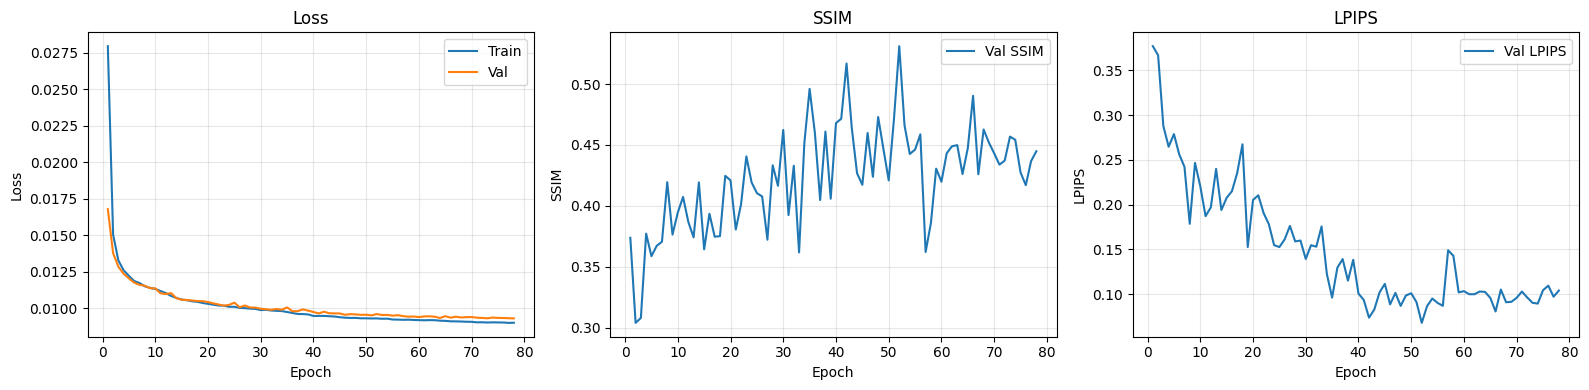

In [17]:
# Plot training curves
if metric_history:
    epochs = np.arange(1, len(metric_history) + 1)
    train_loss = np.array([m['train_loss'] for m in metric_history], dtype=float)
    val_loss = np.array([m['val_loss'] for m in metric_history], dtype=float)
    val_ssim = np.array([m['val_ssim'] if m['val_ssim'] is not None else np.nan for m in metric_history], dtype=float)
    val_lpips = np.array([m['val_lpips'] if m['val_lpips'] is not None else np.nan for m in metric_history], dtype=float)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(epochs, train_loss, label='Train')
    axes[0].plot(epochs, val_loss, label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, val_ssim, label='Val SSIM')
    axes[1].set_title('SSIM')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('SSIM')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(epochs, val_lpips, label='Val LPIPS')
    axes[2].set_title('LPIPS')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LPIPS')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No metrics logged yet.')

## 14. Inference helpers
These functions generate ad‑hoc samples or roll out multiple steps from a given context window.

In [18]:
def _stack_context_paths(ctx_paths: list[str]) -> torch.Tensor:
    """Load k context images into a single [1,k,H,W] tensor."""
    assert len(ctx_paths) == CONTEXT_K, f"Expected {CONTEXT_K} context paths"
    ctx_tensors = [load_image(p).squeeze(0) for p in ctx_paths]  # [k, H, W]
    return torch.stack(ctx_tensors, dim=0).unsqueeze(0)  # [1, k, H, W]

def _infer_frame_index(path: str) -> int | None:
    """Infer frame index from filename like 00037.jpeg/jpg."""
    base = os.path.basename(path)
    m = re.search(r"(\d+)\.jpe?g$", base)
    return int(m.group(1)) if m else None

def _infer_time_scalar(context_paths: list[str], max_frame_index: int | None = None) -> float:
    # Use last context frame index as t_end; normalize by max_frame_index if provided
    t_end = _infer_frame_index(context_paths[-1])
    if t_end is None:
        return 0.0
    if max_frame_index is None or max_frame_index <= 0:
        max_frame_index = t_end
    return float(t_end) / float(max(1, max_frame_index))

def visualize_samples(num=4, plane='F0', save_dir: str | None = None):
    """Save the same sample grids as training: mixed, transition, and rollout grids."""
    if save_dir is None:
        save_dir = OUT_SAMPLES_DIR / 'ad_hoc_samples' / plane
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # Mixed samples
    samples = val_dataset.sample_pairs_for_plane(plane, num)
    if samples:
        _save_sample_grid(samples, save_dir, title_suffix='(mixed)')

    # Transitional-only samples
    trans_dir = save_dir / 'transitions'
    trans_samples = val_dataset.sample_transition_pairs_for_plane(plane, num)
    if trans_samples:
        _save_sample_grid(trans_samples, trans_dir, title_suffix='(transition)')

    # Rollout grid (single seed)
    rollout_dir = save_dir / 'rollouts'
    rollout_seed = val_dataset.sample_pairs_for_plane(plane, 1)
    if rollout_seed:
        _save_rollout_grid(rollout_seed[0], rollout_dir, steps=CONTEXT_K)

    print(f"Ad hoc samples saved to {save_dir}")

def predict_next_frame(context_paths: list[str], out_path: str, max_frame_index: int | None = None):
    """Generate the next frame given k context frames."""
    assert len(context_paths) == CONTEXT_K, f"Need exactly {CONTEXT_K} context frames"
    x_ctx = _stack_context_paths(context_paths).to(device)
    frame_idx = None
    if USE_TIME_MAP:
        t_end = _infer_frame_index(context_paths[-1]) or 0
        frame_idx = min(int(t_end + 1), int(MAX_FRAME_INDEX))
        frame_idx = torch.tensor([frame_idx], device=device, dtype=torch.long)
    x_gen = sample_from_model(
        (1, 1, IMG_SIZE, IMG_SIZE),
        x_ctx=x_ctx,
        frame_idx=frame_idx,
    )
    out_path = str(out_path)
    save_tensor_image(x_gen[0], out_path)
    return out_path

def rollout_next_frames(
    initial_context_paths: list[str],
    steps: int,
    out_dir: str,
    max_frame_index: int | None = None
):
    """Multi-step rollout with a moving context window."""
    assert len(initial_context_paths) == CONTEXT_K, f"Need exactly {CONTEXT_K} context frames"
    os.makedirs(out_dir, exist_ok=True)

    # initialize context tensors (each [1, H, W]) in [-1,1]
    ctx_tensors = [load_image(p) for p in initial_context_paths]
    t_end = _infer_frame_index(initial_context_paths[-1]) or 0
    
    generated_paths = []
    frame_idx = min(int(t_end + 1), int(MAX_FRAME_INDEX))
    for step in range(1, steps + 1):
        x_ctx = torch.stack([t.squeeze(0) for t in ctx_tensors], dim=0).unsqueeze(0).to(device)
        if USE_TIME_MAP:
            frame_idx = min(frame_idx, int(MAX_FRAME_INDEX))
            frame_idx_tensor = torch.tensor([frame_idx], device=device, dtype=torch.long)
        else:
            frame_idx_tensor = None
        x_gen = sample_from_model(
            (1, 1, IMG_SIZE, IMG_SIZE),
            x_ctx=x_ctx,
            frame_idx=frame_idx_tensor,
        )
        save_path = os.path.join(out_dir, f'gen_t{t_end+1:05d}.png')
        save_tensor_image(x_gen[0], save_path)
        generated_paths.append(save_path)

        # update context window: drop oldest, append generated
        ctx_tensors = ctx_tensors[1:] + [x_gen[0].detach().cpu()]
        t_end += 1
        frame_idx += 1

    return generated_paths

visualize_samples()

Ad hoc samples saved to /home/khasion/Projects/thesis/diffusion/diffusion_samples/ad_hoc_samples/F0
